# Análise de Correspondência Múltipla (MCA)

## Dataset: Bank Marketing — UCI Machine Learning Repository

Este notebook aplica **Análise de Correspondência Múltipla (MCA)** em um dataset real e relativamente grande da web: o **Bank Marketing Dataset**, disponibilizado pela UCI Machine Learning Repository.

O conjunto de dados contém informações de campanhas de marketing direto de uma instituição bancária portuguesa. As campanhas foram realizadas principalmente por contato telefônico, e o objetivo original do dataset era analisar se o cliente assinaria ou não um depósito a prazo.

Neste notebook, o foco **não é criar um modelo supervisionado de classificação**. O objetivo é usar a MCA como técnica **não supervisionada** para investigar associações entre variáveis categóricas, como:

- perfil profissional;
- estado civil;
- escolaridade;
- existência de financiamento;
- canal de contato;
- mês da campanha;
- resultado da campanha anterior;
- assinatura ou não do produto bancário.

## Diferença prática entre ANACOR e MCA

Na **ANACOR**, o input mais comum é uma **matriz de contingência**, isto é, uma tabela cruzada entre duas variáveis categóricas.

Na **MCA**, o input é o **banco de dados original**, contendo várias variáveis categóricas. A MCA amplia a lógica da Análise de Correspondência para mais de duas variáveis categóricas.

Em termos simples:


\text{ANACOR} \rightarrow \text{matriz de contingência}



\text{MCA} \rightarrow \text{base original com variáveis categóricas}


In [1]:
#%% Importando os pacotes necessários

import io
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import prince

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

## 1. Carregando o dataset da web

O arquivo será baixado diretamente da UCI. Dentro do arquivo `.zip`, usaremos o arquivo `bank-full.csv`, que contém a base completa da versão clássica do Bank Marketing Dataset.

In [2]:
#%% Baixando e lendo o dataset da UCI

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print(z.namelist())
    with z.open("bank-full.csv") as f:
        df = pd.read_csv(f, sep=';')

print(df.shape)
df.head()

['bank-full.csv', 'bank-names.txt', 'bank.csv']
(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Entendendo as variáveis

A base possui variáveis numéricas e categóricas. Como a MCA trabalha com variáveis categóricas, serão utilizadas diretamente as variáveis categóricas e algumas variáveis numéricas serão transformadas em faixas.

Essa transformação é comum quando queremos representar características numéricas em categorias interpretáveis.

In [3]:
#%% Informações gerais da base

print(df.info())
print("\nQuantidade de valores ausentes por coluna:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Quantidade de valores ausentes por coluna:
age          0
job          0
marital      0
educa

In [4]:
#%% Frequências das principais variáveis categóricas

cat_cols_originais = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome', 'y'
]

for col in cat_cols_originais:
    print(f"\nVariável: {col}")
    print(df[col].value_counts(dropna=False))


Variável: job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

Variável: marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

Variável: education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

Variável: default
default
no     44396
yes      815
Name: count, dtype: int64

Variável: housing
housing
yes    25130
no     20081
Name: count, dtype: int64

Variável: loan
loan
no     37967
yes     7244
Name: count, dtype: int64

Variável: contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

Variável: month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2

## 3. Preparação da base para MCA

A MCA funciona melhor quando as categorias estão claras e com nomes interpretáveis. Por isso, criaremos algumas faixas para variáveis numéricas:

- `faixa_idade`;
- `faixa_saldo`;
- `faixa_duracao_contato`;
- `faixa_contatos_campanha`.

Depois, selecionaremos apenas variáveis categóricas para a análise.

In [5]:
#%% Criando faixas categóricas para variáveis numéricas

df_mca = df.copy()

# Faixas de idade
df_mca['faixa_idade'] = pd.cut(
    df_mca['age'],
    bins=[17, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)

# Faixas de saldo bancário
# Usa qcut para criar grupos por quantis, evitando faixas muito desbalanceadas.
df_mca['faixa_saldo'] = pd.qcut(
    df_mca['balance'],
    q=4,
    labels=['saldo_baixo', 'saldo_medio_baixo', 'saldo_medio_alto', 'saldo_alto'],
    duplicates='drop'
)

# Faixas de duração do último contato
# Observação: duration é uma variável muito informativa para classificação, mas aqui será usada apenas como categoria exploratória.
df_mca['faixa_duracao_contato'] = pd.qcut(
    df_mca['duration'],
    q=4,
    labels=['duracao_baixa', 'duracao_media_baixa', 'duracao_media_alta', 'duracao_alta'],
    duplicates='drop'
)

# Faixas de quantidade de contatos na campanha atual
df_mca['faixa_contatos_campanha'] = pd.cut(
    df_mca['campaign'],
    bins=[0, 1, 2, 5, df_mca['campaign'].max()],
    labels=['1_contato', '2_contatos', '3_a_5_contatos', 'mais_de_5_contatos'],
    include_lowest=True
)

# Padronizando a variável resposta como uma categoria interpretável
# Ela não será usada como target supervisionado, apenas como mais uma categoria na MCA.
df_mca['assinou_deposito'] = df_mca['y'].map({'yes': 'assinou', 'no': 'nao_assinou'})

In [6]:
#%% Selecionando variáveis categóricas para a MCA

variaveis_mca = [
    'faixa_idade',
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'faixa_saldo',
    'faixa_duracao_contato',
    'faixa_contatos_campanha',
    'assinou_deposito'
]

base_mca = df_mca[variaveis_mca].copy()

# Garantindo que todas as colunas estejam como texto/categoria
base_mca = base_mca.astype(str)

print(base_mca.shape)
base_mca.head()

(45211, 13)


,faixa_idade,job,marital,education,housing,loan,contact,month,poutcome,faixa_saldo,faixa_duracao_contato,faixa_contatos_campanha,assinou_deposito
0,46-60,management,married,tertiary,yes,no,unknown,may,unknown,saldo_alto,duracao_media_alta,1_contato,nao_assinou
1,31-45,technician,single,secondary,yes,no,unknown,may,unknown,saldo_baixo,duracao_media_baixa,1_contato,nao_assinou
2,31-45,entrepreneur,married,secondary,yes,yes,unknown,may,unknown,saldo_baixo,duracao_baixa,1_contato,nao_assinou
3,46-60,blue-collar,married,unknown,yes,no,unknown,may,unknown,saldo_alto,duracao_baixa,1_contato,nao_assinou
4,31-45,unknown,single,unknown,no,no,unknown,may,unknown,saldo_baixo,duracao_media_alta,1_contato,nao_assinou


## 4. Tabelas de contingência e teste qui-quadrado

Antes de aplicar a MCA, podemos verificar algumas associações bivariadas usando tabelas de contingência e o teste qui-quadrado.

Esse passo é semelhante ao que fazemos na ANACOR, mas aqui serve apenas como uma exploração inicial, pois a MCA analisará várias variáveis categóricas simultaneamente.

In [7]:
#%% Função auxiliar para teste qui-quadrado entre duas variáveis categóricas

def teste_qui2(var_linha, var_coluna, dados=base_mca):
    tabela = pd.crosstab(dados[var_linha], dados[var_coluna])
    qui2, pvalor, gl, esperadas = chi2_contingency(tabela)
    print(f"Variáveis analisadas: {var_linha} x {var_coluna}")
    print(f"Estatística qui-quadrado: {qui2:.2f}")
    print(f"p-valor: {pvalor:.6f}")
    print(f"Graus de liberdade: {gl}")
    display(tabela)
    return tabela

# Exemplos de associações bivariadas
_ = teste_qui2('job', 'assinou_deposito')
_ = teste_qui2('education', 'assinou_deposito')
_ = teste_qui2('contact', 'assinou_deposito')

Variáveis analisadas: job x assinou_deposito
Estatística qui-quadrado: 836.11
p-valor: 0.000000
Graus de liberdade: 11


assinou_deposito,assinou,nao_assinou
job,,
admin.,631,4540
blue-collar,708,9024
entrepreneur,123,1364
housemaid,109,1131
management,1301,8157
retired,516,1748
self-employed,187,1392
services,369,3785
student,269,669


Variáveis analisadas: education x assinou_deposito
Estatística qui-quadrado: 238.92
p-valor: 0.000000
Graus de liberdade: 3


assinou_deposito,assinou,nao_assinou
education,,
primary,591,6260
secondary,2450,20752
tertiary,1996,11305
unknown,252,1605


Variáveis analisadas: contact x assinou_deposito
Estatística qui-quadrado: 1035.71
p-valor: 0.000000
Graus de liberdade: 2


assinou_deposito,assinou,nao_assinou
contact,,
cellular,4369,24916
telephone,390,2516
unknown,530,12490


## 5. Aplicando a MCA

A MCA transforma as categorias em coordenadas numéricas. Assim, cada categoria passa a ter uma posição no mapa perceptual.

A ideia é parecida com a ANACOR:

- os **autovalores** indicam quanta inércia cada dimensão explica;
- os **autovetores** ajudam a definir a direção dos eixos;
- as **coordenadas** posicionam as categorias no plano;
- o **mapa perceptual** permite visualizar proximidades entre categorias.

In [8]:
#%% Ajustando o modelo de MCA

mca = prince.MCA(
    n_components=5,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca = mca.fit(base_mca)

In [9]:
#%% Obtendo os autovalores e a inércia explicada

# Os autovalores indicam quanta informação cada dimensão explica.
# Na MCA e na ANACOR, essa informação é chamada de inércia.
# Quanto maior o percentual de inércia, maior a importância da dimensão.

tabela_autovalores = mca.eigenvalues_summary

print(tabela_autovalores)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.189         5.22%                      5.22%
1              0.155         4.30%                      9.52%
2              0.143         3.96%                     13.49%
3              0.123         3.41%                     16.90%
4              0.118         3.26%                     20.16%


In [10]:
#%% Interpretando as duas primeiras dimensões

# Em mapas perceptuais, normalmente usamos as duas primeiras dimensões:
# Dimensão 1 = eixo X
# Dimensão 2 = eixo Y

inercia_dim1 = tabela_autovalores.iloc[0, 1]
inercia_dim2 = tabela_autovalores.iloc[1, 1]
inercia_acumulada = tabela_autovalores.iloc[1, 2]

print(f"Dimensão 1: {inercia_dim1} da inércia")
print(f"Dimensão 2: {inercia_dim2} da inércia")
print(f"Inércia acumulada nas duas primeiras dimensões: {inercia_acumulada}")

Dimensão 1: 5.22% da inércia
Dimensão 2: 4.30% da inércia
Inércia acumulada nas duas primeiras dimensões: 9.52%


## 6. Coordenadas das categorias

Na MCA, cada categoria recebe coordenadas nas dimensões calculadas. Essas coordenadas permitem transformar categorias em pontos no plano.

Esse é um ponto importante: a MCA cria uma representação métrica para dados categóricos.

In [11]:
#%% Coordenadas das categorias

coord_categorias = mca.column_coordinates(base_mca)
coord_categorias = coord_categorias.reset_index()
coord_categorias.columns = ['categoria', 'Dim_1', 'Dim_2', 'Dim_3', 'Dim_4', 'Dim_5']

coord_categorias.head(20)

# Onde Dim_1 é o eixo x do gráfico, Dim_2 é o eixo y do gráfico e assim por diante, abaixo temos 5 dimensões.

,categoria,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5
0,faixa_idade__18-30,0.050535,-1.060610,0.553272,0.675492,0.775384
1,faixa_idade__31-45,-0.176385,-0.225342,-0.150094,-0.141729,-0.251320
2,faixa_idade__46-60,0.047495,0.753197,-0.216593,-0.083849,0.041934
3,faixa_idade__60+,2.694533,2.371000,2.142005,-0.229977,-0.035717
4,job__admin.,-0.227028,-0.371605,0.384845,-0.287711,0.505452
5,job__blue-collar,-0.738164,0.377284,0.472328,-0.218589,-0.168125
6,job__entrepreneur,-0.137745,0.180197,-0.465811,-0.261636,-0.423513
7,job__housemaid,0.139814,1.422341,-0.340463,0.150796,0.446809
8,job__management,0.558716,-0.371797,-0.881305,0.339333,-0.928834
9,job__retired,1.455956,2.167174,1.218724,-0.177870,0.211862


In [12]:
#%% Separando o nome da variável e da categoria

# O prince normalmente retorna categorias no formato: variavel__categoria
# Dependendo da versão do pacote, o separador pode variar.
# A rotina abaixo tenta organizar esse texto para facilitar a leitura.

def separar_variavel_categoria(texto):
    texto = str(texto)
    if '__' in texto:
        partes = texto.split('__', 1)
    elif '_' in texto:
        # fallback simples: separa apenas na primeira ocorrência
        partes = texto.split('_', 1)
    else:
        partes = ['categoria', texto]
    return pd.Series(partes[:2])

coord_categorias[['variavel', 'valor_categoria']] = coord_categorias['categoria'].apply(separar_variavel_categoria)
coord_categorias.head(20)

,categoria,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5,variavel,valor_categoria
0,faixa_idade__18-30,0.050535,-1.060610,0.553272,0.675492,0.775384,faixa_idade,18-30
1,faixa_idade__31-45,-0.176385,-0.225342,-0.150094,-0.141729,-0.251320,faixa_idade,31-45
2,faixa_idade__46-60,0.047495,0.753197,-0.216593,-0.083849,0.041934,faixa_idade,46-60
3,faixa_idade__60+,2.694533,2.371000,2.142005,-0.229977,-0.035717,faixa_idade,60+
4,job__admin.,-0.227028,-0.371605,0.384845,-0.287711,0.505452,job,admin.
5,job__blue-collar,-0.738164,0.377284,0.472328,-0.218589,-0.168125,job,blue-collar
6,job__entrepreneur,-0.137745,0.180197,-0.465811,-0.261636,-0.423513,job,entrepreneur
7,job__housemaid,0.139814,1.422341,-0.340463,0.150796,0.446809,job,housemaid
8,job__management,0.558716,-0.371797,-0.881305,0.339333,-0.928834,job,management
9,job__retired,1.455956,2.167174,1.218724,-0.177870,0.211862,job,retired


## 7. Mapa perceptual da MCA

O mapa perceptual representa as categorias no plano definido pelas duas primeiras dimensões.

Categorias próximas no gráfico tendem a aparecer associadas nos padrões da base. Categorias distantes indicam menor associação ou comportamento diferente.

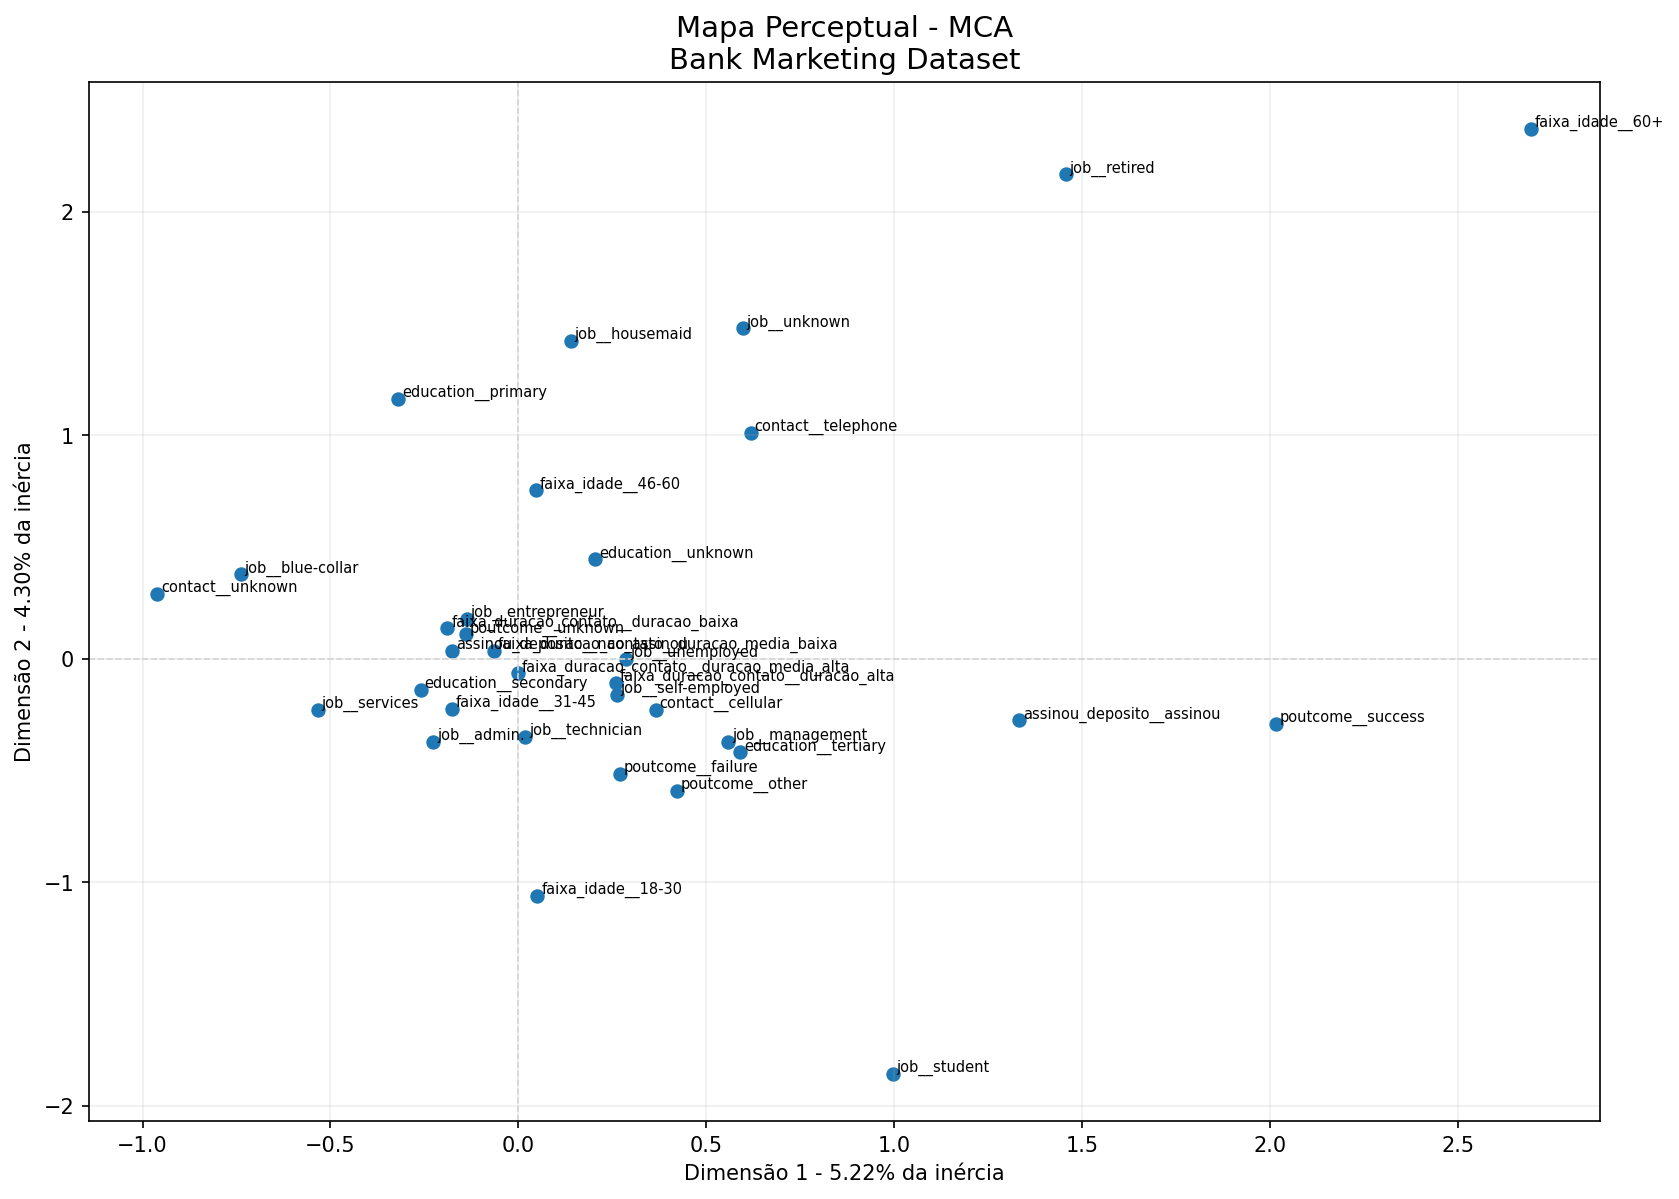

In [13]:
#%% Plotando o mapa perceptual da MCA

plt.figure(figsize=(13, 9), dpi=150)

# Para manter o gráfico legível, podemos filtrar algumas variáveis principais.
variaveis_plot = [
    'faixa_idade', 'job', 'education', 'contact',
    'poutcome', 'faixa_duracao_contato', 'assinou_deposito'
]

plot_df = coord_categorias[coord_categorias['variavel'].isin(variaveis_plot)].copy()

plt.scatter(plot_df['Dim_1'], plot_df['Dim_2'], s=35)

for _, row in plot_df.iterrows():
    plt.text(
        row['Dim_1'] + 0.01,
        row['Dim_2'] + 0.01,
        row['categoria'],
        fontsize=7
    )

plt.axhline(0, color='lightgrey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='lightgrey', linestyle='--', linewidth=0.8)
plt.title('Mapa Perceptual - MCA\nBank Marketing Dataset', fontsize=14)
plt.xlabel(f"Dimensão 1 - {inercia_dim1} da inércia")
plt.ylabel(f"Dimensão 2 - {inercia_dim2} da inércia")
plt.grid(alpha=0.2)
plt.show()

## 8. Coordenadas das observações

Além das categorias, a MCA também permite obter coordenadas para cada observação da base. Isso pode ser útil para visualizar grupos de clientes com perfis semelhantes.

Como a base é grande, o gráfico abaixo usa uma amostra para evitar poluição visual.

In [14]:
#%% Coordenadas das observações

coord_observacoes = mca.row_coordinates(base_mca)
coord_observacoes = coord_observacoes.rename(columns={0: 'Dim_1', 1: 'Dim_2'})
coord_observacoes['assinou_deposito'] = base_mca['assinou_deposito'].values

coord_observacoes.head()

,Dim_1,Dim_2,2,3,4,assinou_deposito
0,-0.160005,0.062291,-0.112480,0.289906,-0.768539,nao_assinou
1,-0.549881,-0.331181,0.149823,0.168295,0.039156,nao_assinou
2,-0.706742,0.049260,-0.058255,-0.148048,-0.079991,nao_assinou
3,-0.490900,0.416246,0.269808,0.334428,-0.323221,nao_assinou
4,-0.157373,0.212176,0.227831,1.033749,0.134713,nao_assinou


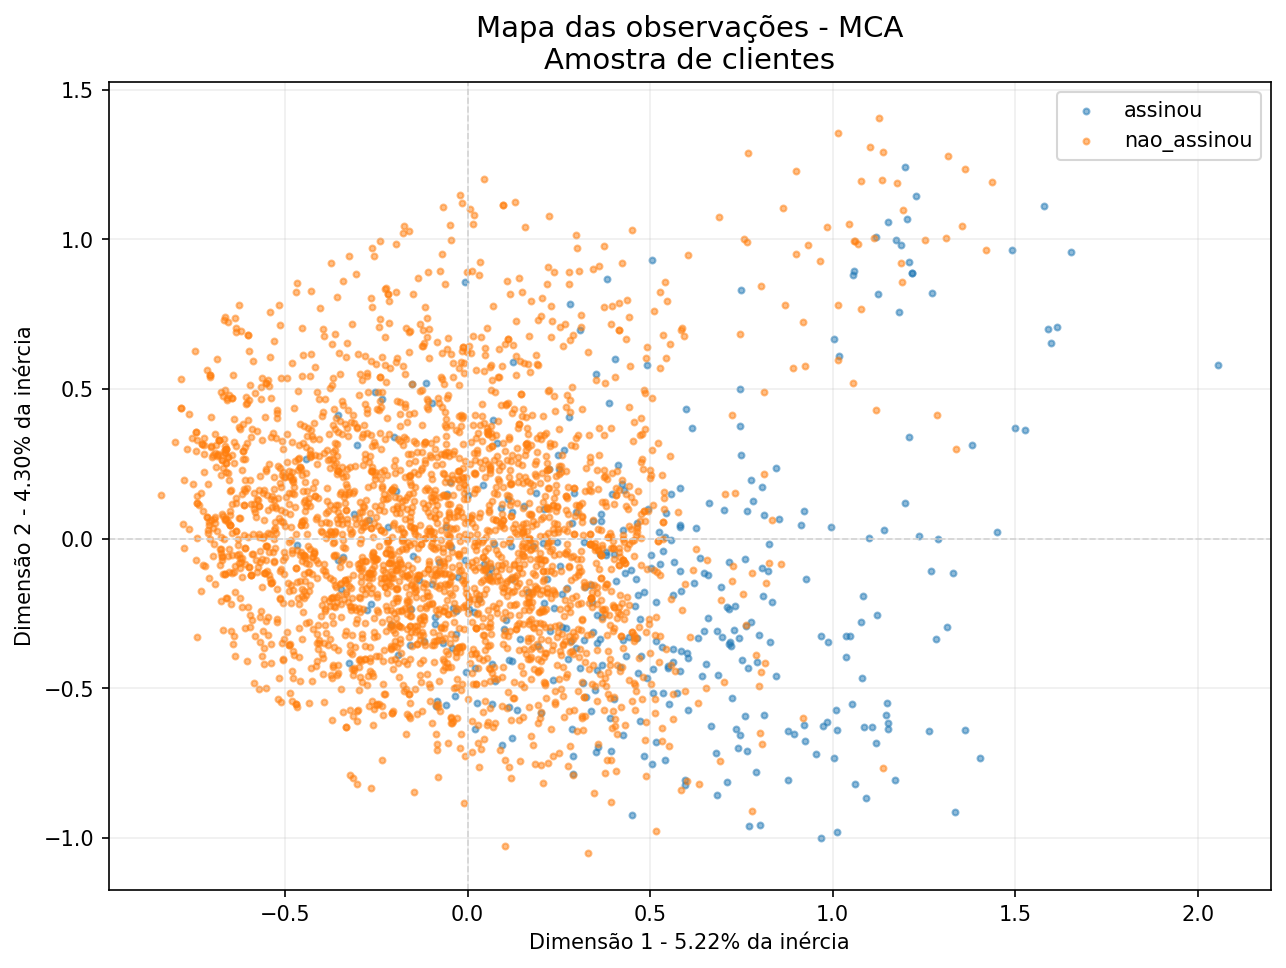

In [15]:
#%% Plotando uma amostra das observações

amostra_obs = coord_observacoes.sample(n=3000, random_state=42)

plt.figure(figsize=(10, 7), dpi=150)

for classe, dados_classe in amostra_obs.groupby('assinou_deposito'):
    plt.scatter(
        dados_classe['Dim_1'],
        dados_classe['Dim_2'],
        s=8,
        alpha=0.5,
        label=classe
    )

plt.axhline(0, color='lightgrey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='lightgrey', linestyle='--', linewidth=0.8)
plt.title('Mapa das observações - MCA\nAmostra de clientes', fontsize=14)
plt.xlabel(f"Dimensão 1 - {inercia_dim1} da inércia")
plt.ylabel(f"Dimensão 2 - {inercia_dim2} da inércia")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 9. Categorias mais próximas da assinatura do depósito

Como as categorias foram transformadas em coordenadas, podemos calcular distâncias entre pontos no mapa perceptual.

A distância euclidiana entre duas categorias é dada por:

\[
d(A,B) = \sqrt{(x_A - x_B)^2 + (y_A - y_B)^2}
\]

Atenção: proximidade no mapa ajuda na interpretação exploratória, mas não deve ser tratada como causalidade.

In [16]:
#%% Calculando categorias próximas de "assinou_deposito__assinou"

# Localizando a categoria de interesse.
# Dependendo da versão do prince, o nome pode variar levemente.
coord_categorias[['categoria', 'Dim_1', 'Dim_2']].head()

categoria_interesse = coord_categorias[coord_categorias['categoria'].str.contains('assinou', case=False, regex=False)]
print(categoria_interesse[['categoria', 'Dim_1', 'Dim_2']])

                        categoria     Dim_1     Dim_2
58      assinou_deposito__assinou  1.332558 -0.275697
59  assinou_deposito__nao_assinou -0.176542  0.036525


In [17]:
#%% Distância euclidiana até a categoria associada à assinatura

# Escolhe a categoria que contém "assinou" e não contém "nao", quando disponível.
candidatos = coord_categorias[
    coord_categorias['categoria'].str.contains('assinou', case=False, regex=False)
    & ~coord_categorias['categoria'].str.contains('nao', case=False, regex=False)
]

if len(candidatos) == 0:
    print("Categoria 'assinou' não encontrada de forma direta. Verifique os nomes retornados em coord_categorias.")
else:
    alvo = candidatos.iloc[0]
    x_alvo, y_alvo = alvo['Dim_1'], alvo['Dim_2']

    distancias = coord_categorias.copy()
    distancias['distancia_ate_assinou'] = np.sqrt(
        (distancias['Dim_1'] - x_alvo) ** 2 +
        (distancias['Dim_2'] - y_alvo) ** 2
    )

    distancias = distancias[distancias['categoria'] != alvo['categoria']]
    display(distancias.sort_values('distancia_ate_assinou').head(15)[
        ['categoria', 'Dim_1', 'Dim_2', 'distancia_ate_assinou']
    ])

,categoria,Dim_1,Dim_2,distancia_ate_assinou
37,month__mar,1.832295,-0.238662,0.501107
44,poutcome__success,2.016100,-0.292368,0.683745
33,month__feb,0.648854,-0.333275,0.686124
41,month__sep,2.011353,-0.031673,0.721325
34,month__jan,0.616355,-0.467943,0.741556
21,education__tertiary,0.590277,-0.418853,0.755959
8,job__management,0.558716,-0.371797,0.779787
31,month__aug,0.707146,0.219672,0.797829
40,month__oct,1.878720,0.344236,0.826202
32,month__dec,2.072938,0.102073,0.831187


## 10. Interpretação final

A MCA permitiu transformar várias variáveis categóricas em coordenadas numéricas. Com isso, foi possível visualizar associações entre categorias no mapa perceptual.

Em uma leitura geral:

- categorias próximas tendem a estar associadas;
- categorias distantes tendem a representar perfis diferentes;
- as duas primeiras dimensões resumem parte da inércia total;
- a análise é exploratória e não indica causalidade.

Diferentemente da ANACOR, que normalmente parte de uma matriz de contingência com duas variáveis, a MCA parte da base original e permite analisar simultaneamente múltiplas variáveis categóricas.

## Referência da base

Bank Marketing Dataset — UCI Machine Learning Repository. Dataset relacionado a campanhas de marketing direto de uma instituição bancária portuguesa.

Página da base: https://archive.ics.uci.edu/dataset/222/bank+marketing